# Impact of Artificial Intelligence on Job Status: A Comprehensive Machine Learning Analysis

## Problem Statement
**Predict which employees are at high risk of job replacement due to AI adoption, so HR and management can intervene early with upskilling, role modification, or strategic redeployment.**

## Project Overview
This project analyzes and predicts the impact of AI on various job roles across different industries. Using a dataset capturing employee demographics, experience, and AI-related metrics, we employ multiple machine learning models to classify the 'Job Status' (Replaced, Modified, or Unchanged).

## Objectives
1. **Exploratory Data Analysis (EDA):** Understand feature distributions and relationships, focusing on salary changes and industry-specific impacts.
2. **Feature Engineering:** Create derived metrics like salary change percentage and experience brackets to improve model performance.
3. **Model Benchmarking & Optimization:** Compare multiple classification algorithms, tune hyperparameters, and address class imbalance.
4. **Actionable Insights:** Identify key drivers of job displacement, profile at-risk employees, and quantify financial impact.
5. **Model Interpretability:** Use feature importance and advanced techniques to explain *why* certain roles are at higher risk.

In [1]:
import subprocess
import sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn"])

0

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from imblearn.ensemble import BalancedRandomForestClassifier    # pip install imblearn
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score, roc_auc_score)
from sklearn.utils.class_weight import compute_class_weight

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
warnings.filterwarnings('ignore')

In [3]:
# Load the dataset
df = pd.read_csv("ai_job_impact.csv")

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (2000, 17)


,Employee_ID,Age,Gender,Education_Level,Industry,Job_Role,Years_Experience,AI_Adoption_Level,Automation_Risk,Upskilling_Required,Salary_Before_AI,Salary_After_AI,Job_Status,Work_Hours_Per_Week,Remote_Work,Job_Satisfaction,Productivity_Change_%
0,E0001,50,Female,Bachelor,Marketing,Content Creator,26,High,High,Yes,106820,95455,Replaced,45,No,5,-10.64
1,E0002,45,Male,High School,Manufacturing,Quality Inspector,19,Low,Low,Yes,74131,72013,Unchanged,36,Yes,6,19.05
2,E0003,51,Female,Master,IT,DevOps Engineer,28,Medium,Medium,Yes,35311,42290,Modified,46,Yes,3,17.05
3,E0004,48,Male,PhD,Education,Teacher,24,Medium,Medium,Yes,114478,107820,Modified,50,No,9,-2.47
4,E0005,24,Male,Bachelor,Healthcare,Doctor,0,High,Medium,No,33890,40945,Modified,52,Yes,6,7.03


## 1. Exploratory Data Analysis (EDA)

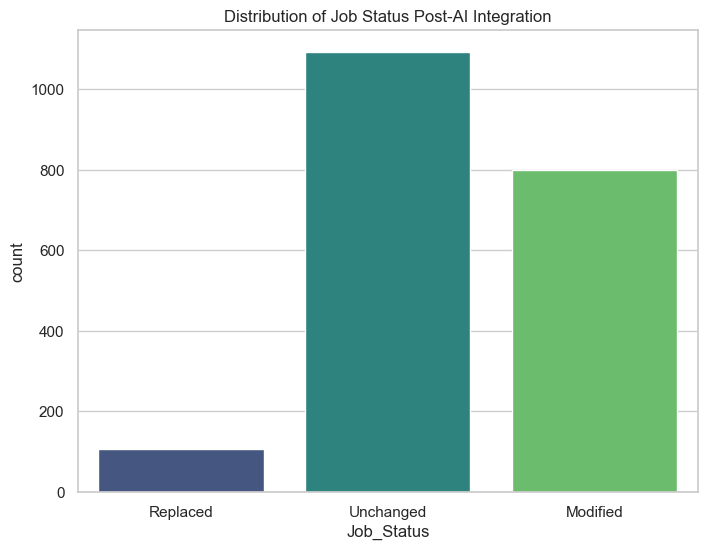

Class Distribution (%):
Job_Status
Unchanged    54.65
Modified     40.05
Replaced      5.30
Name: proportion, dtype: float64


In [4]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Job_Status', palette='viridis')
plt.title('Distribution of Job Status Post-AI Integration')
plt.show()

print("Class Distribution (%):")
print(df['Job_Status'].value_counts(normalize=True) * 100)

<Figure size 1000x600 with 0 Axes>

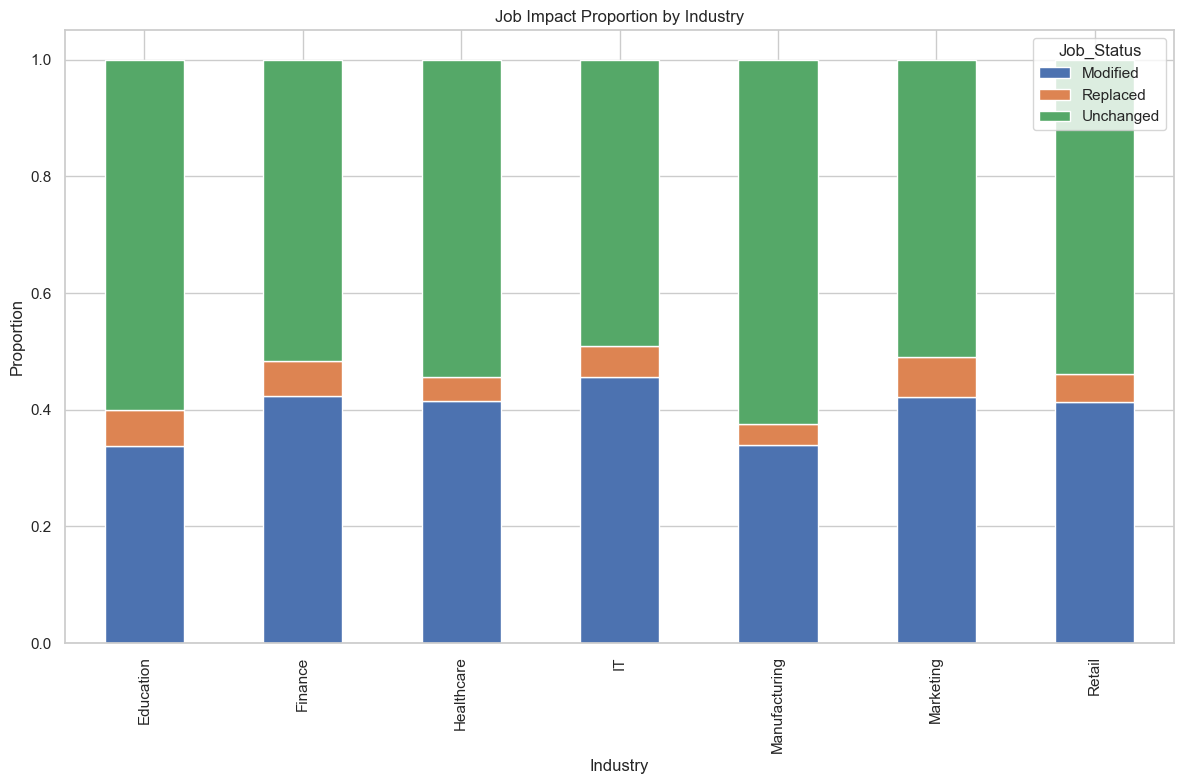


📊 Average Salary Change by Job Status:
Job_Status
Modified     5283.235955
Replaced     7956.216981
Unchanged    3566.247941
Name: Salary_Change, dtype: float64


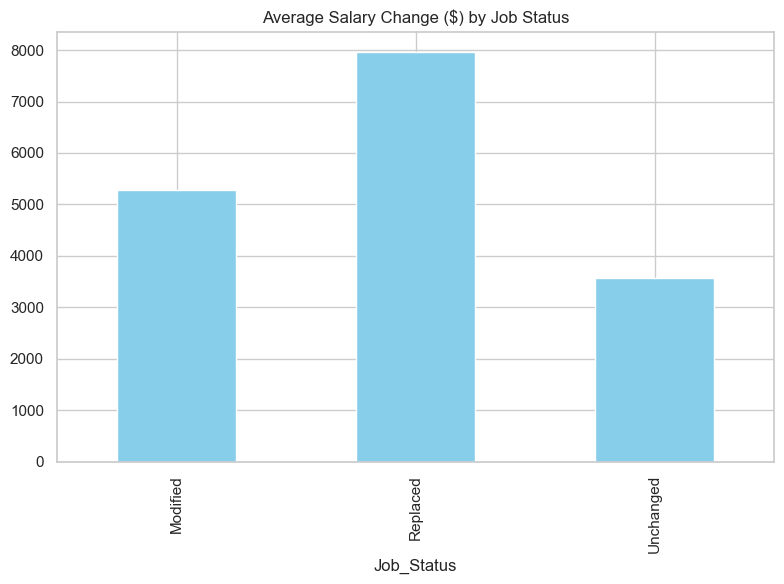


📊 At-Risk Employee Profile (Replaced Group):
       Years_Experience  Salary_Before_AI  Job_Satisfaction
count        106.000000        106.000000        106.000000
mean          17.933962      77600.896226          6.094340
std           10.348470      27828.389774          1.983399
min            0.000000      30336.000000          3.000000
25%            9.000000      52844.250000          4.000000
50%           18.500000      79562.000000          6.000000
75%           26.000000     106180.500000          8.000000
max           37.000000     119532.000000          9.000000


In [5]:
# 🔹 Enhancement 2: Industry-wise breakdown
plt.figure(figsize=(10, 6))
df.groupby('Industry')['Job_Status'].value_counts(normalize=True).unstack().plot(kind='bar', stacked=True)
plt.title('Job Impact Proportion by Industry')
plt.ylabel('Proportion')
plt.tight_layout()
plt.show()

# 🔹 Enhancement 4: Salary impact analysis
df['Salary_Change'] = df['Salary_After_AI'] - df['Salary_Before_AI']
salary_impact = df.groupby('Job_Status')['Salary_Change'].mean()
print("\n📊 Average Salary Change by Job Status:")
print(salary_impact)

plt.figure(figsize=(8, 6))
salary_impact.plot(kind='bar', color='skyblue')
plt.title('Average Salary Change ($) by Job Status')
plt.tight_layout()
plt.show()

# 🔹 Enhancement 3: At-risk employee profiling
replaced = df[df['Job_Status'] == 'Replaced']
print("\n📊 At-Risk Employee Profile (Replaced Group):")
print(replaced[['Years_Experience', 'Salary_Before_AI', 'Automation_Risk', 'Job_Satisfaction']].describe())

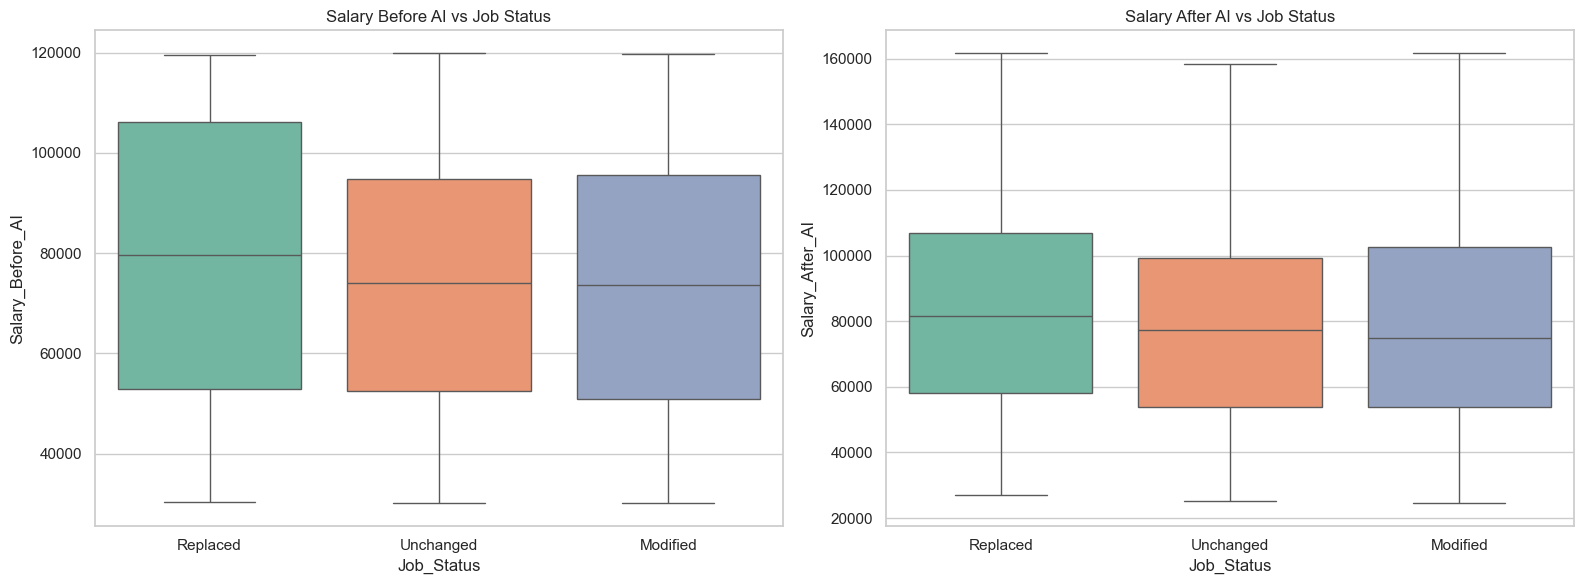

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df, x='Job_Status', y='Salary_Before_AI', ax=axes[0], palette='Set2')
axes[0].set_title('Salary Before AI vs Job Status')

sns.boxplot(data=df, x='Job_Status', y='Salary_After_AI', ax=axes[1], palette='Set2')
axes[1].set_title('Salary After AI vs Job Status')

plt.tight_layout()
plt.show()

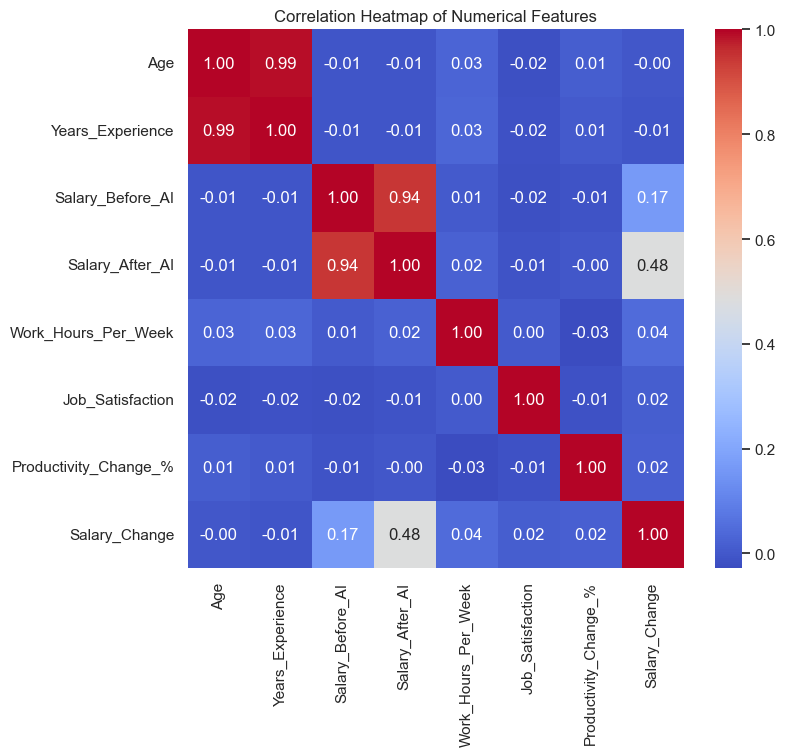

In [7]:
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(8, 7))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

## 2. Feature Engineering
We will create a few new features to capture the relative change in salary and categorize experience levels.

In [8]:
# 1. Salary Change Percentage
df['Salary_Change_Pct'] = ((df['Salary_After_AI'] - df['Salary_Before_AI']) / df['Salary_Before_AI']) * 100

# 2. Experience Bins
df['Exp_Level'] = pd.cut(df['Years_Experience'], bins=[-1, 5, 15, 100], labels=['Junior', 'Mid', 'Senior'])

df[['Salary_Before_AI', 'Salary_After_AI', 'Salary_Change_Pct', 'Exp_Level']].head()

,Salary_Before_AI,Salary_After_AI,Salary_Change_Pct,Exp_Level
0,106820,95455,-10.639393,Senior
1,74131,72013,-2.857104,Senior
2,35311,42290,19.764379,Senior
3,114478,107820,-5.815965,Senior
4,33890,40945,20.817350,Junior


## 3. Data Preprocessing
Preparing the data for machine learning models.

In [9]:
# Drop ID column
if 'Employee_ID' in df.columns:
    df = df.drop('Employee_ID', axis=1)

# Separate Features and Target
X = df.drop('Job_Status', axis=1)
y = df['Job_Status']

# Encode Target
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_

# One-Hot Encoding for Categorical Features
X = pd.get_dummies(X, drop_first=True)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)
# ============================================
# Handle Class Imbalance: Compute Class Weights
# ============================================

# Compute balanced class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))

print("Class weights:", class_weight_dict)
print("\nClass distribution in training set:")
print(pd.Series(y_train).value_counts())

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Class weights: {np.int64(0): np.float64(0.8320332813312532), np.int64(1): np.float64(6.2745098039215685), np.int64(2): np.float64(0.6102212051868803)}

Class distribution in training set:
2    874
0    641
1     85
Name: count, dtype: int64
Training set size: (1600, 48)
Testing set size: (400, 48)


## 4. Model Benchmarking

In [11]:
# Define models to compare
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = []

for name, model in models.items():
    # Cross-validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)

    # Fit and Predict
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append({
        "Model": name,
        "CV Mean Accuracy": cv_scores.mean(),
        "Test Accuracy": acc,
        "F1 Score (Weighted)": f1
    })

results_df = pd.DataFrame(results)
display(results_df.sort_values(by='Test Accuracy', ascending=False))

,Model,CV Mean Accuracy,Test Accuracy,F1 Score (Weighted)
2,Gradient Boosting,0.93875,0.9575,0.953705
1,Random Forest,0.93625,0.9450,0.928337
0,Logistic Regression,0.93625,0.9425,0.943078


In [12]:
# 🔰Balanced Random Forest Added (Visible improvements in scoring)

from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score
from sklearn.model_selection import cross_val_score
import pandas as pd

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Balanced Random Forest": BalancedRandomForestClassifier(
        n_estimators=300,
        random_state=42
    )
}

results = []

for name, model in models.items():
    # Cross-validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)

    # Fit and Predict
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')

    results.append({
        "Model": name,
        "CV Mean Accuracy": cv_scores.mean(),
        "Test Accuracy": acc,

        "Balanced Accuracy": balanced_acc,
        "Macro F1": f1_macro,
        "Weighted F1": f1_weighted
    })

results_df = pd.DataFrame(results)
display(results_df.sort_values(by='Test Accuracy', ascending=False))

,Model,CV Mean Accuracy,Test Accuracy,Balanced Accuracy,Macro F1,Weighted F1
2,Gradient Boosting,0.93875,0.9575,0.799107,0.820766,0.953705
1,Random Forest,0.93625,0.9450,0.692163,0.697589,0.928337
0,Logistic Regression,0.93625,0.9425,0.800397,0.797672,0.943078
3,Balanced Random Forest,0.92875,0.9425,0.952083,0.858844,0.949730


## 5. Hyperparameter Tuning (Random Forest)

In [13]:
# ============================================
# Hyperparameter Tuning with Class Weights
# ============================================

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced', class_weight_dict]  # ← Add this line
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42), 
    param_grid, 
    cv=3, 
    scoring='f1_weighted',  # ← Use f1 for imbalanced data
    n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

best_rf = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")

Best Parameters: {'class_weight': {np.int64(0): np.float64(0.8320332813312532), np.int64(1): np.float64(6.2745098039215685), np.int64(2): np.float64(0.6102212051868803)}, 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best CV Score: 0.9252


In [14]:
# ============================================
# 🔰Hyperparameter tuning Balanced Random Forest
# ============================================

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced', class_weight_dict]  # ← Add this line
}

grid_search = GridSearchCV(
    BalancedRandomForestClassifier(random_state=42), 
    param_grid, 
    cv=5, 
    scoring='f1_weighted',  # ← Use f1 for imbalanced data
    n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

best_brf = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")

Best Parameters: {'class_weight': {np.int64(0): np.float64(0.8320332813312532), np.int64(1): np.float64(6.2745098039215685), np.int64(2): np.float64(0.6102212051868803)}, 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best CV Score: 0.9413


## 6. Final Model Evaluation

Classification Report:
              precision    recall  f1-score   support

    Modified       0.98      0.88      0.92       160
    Replaced       0.42      0.62      0.50        21
   Unchanged       0.97      1.00      0.98       219

    accuracy                           0.93       400
   macro avg       0.79      0.83      0.80       400
weighted avg       0.94      0.93      0.93       400



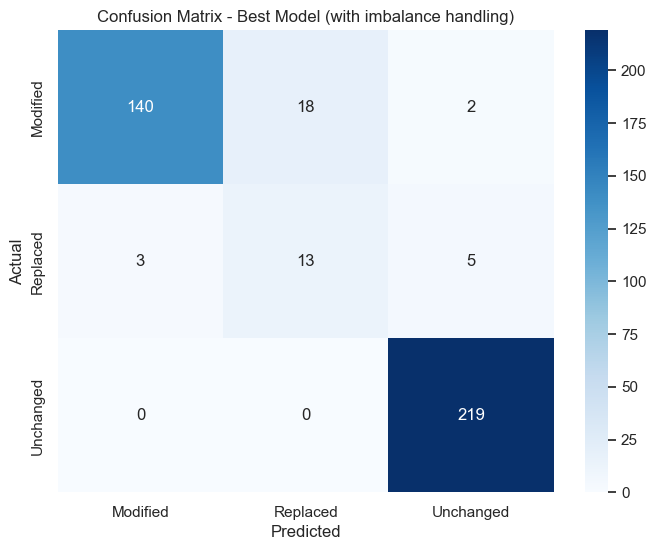

In [15]:
# ============================================
# Final Model Evaluation (No changes needed if using class_weight)
# If using SMOTE, remember to predict on ORIGINAL X_test_scaled
# ============================================

y_pred_final = best_rf.predict(X_test_scaled)  # ← Always use original test set!

print("Classification Report:")
print(classification_report(y_test, y_pred_final, target_names=class_names))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Best Model (with imbalance handling)')
plt.show()

Classification Report:
              precision    recall  f1-score   support

    Modified       1.00      0.86      0.92       160
    Replaced       0.48      1.00      0.65        21
   Unchanged       1.00      1.00      1.00       219

    accuracy                           0.94       400
   macro avg       0.83      0.95      0.86       400
weighted avg       0.97      0.94      0.95       400



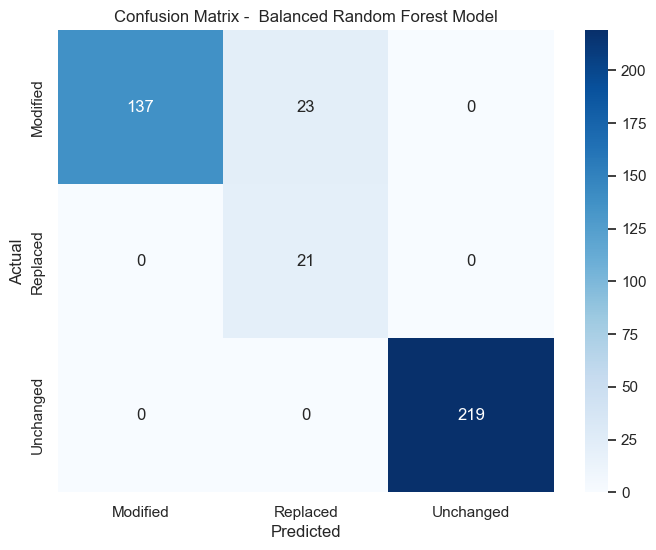

In [16]:
# ============================================
# 🔰Evaluating tunned Balanced Random Forest 
# ============================================

y_pred_final = best_brf.predict(X_test_scaled)  # ← Always use original test set!

print("Classification Report:")
print(classification_report(y_test, y_pred_final, target_names=class_names))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix -  Balanced Random Forest Model')
plt.show()

## 7. Model Interpretability: Feature Importance

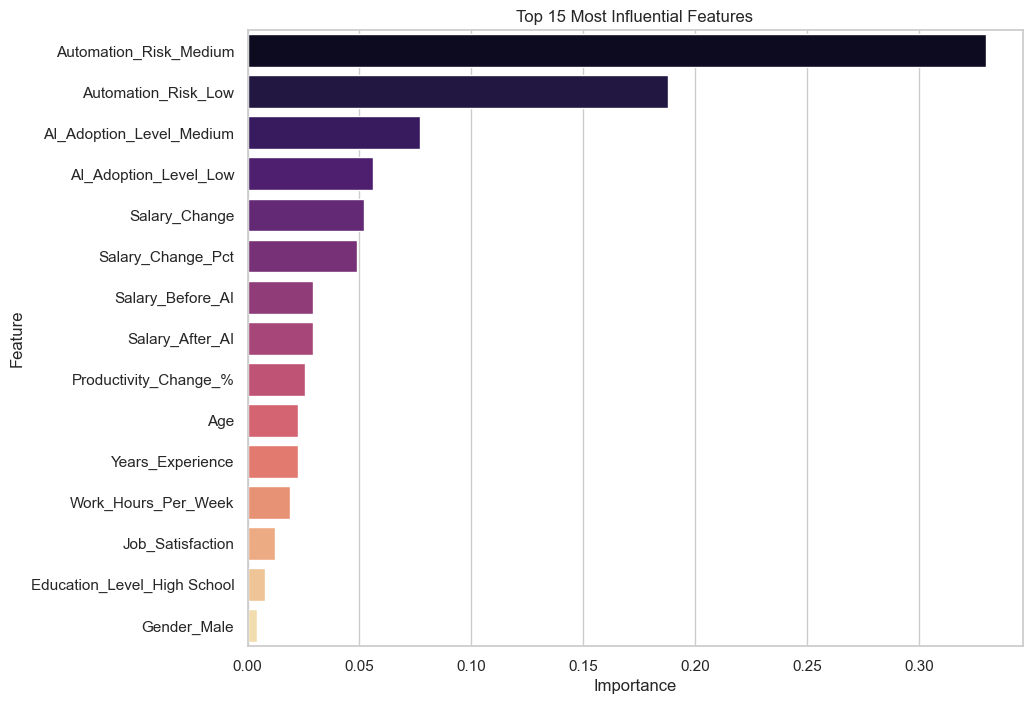

In [17]:
importances = best_rf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='magma')
plt.title('Top 15 Most Influential Features')
plt.show()

## 8. Optimization: Manual Gradient Descent Implementation

To demonstrate a deep understanding of model optimization, we implement a Logistic Regression model from scratch using the Gradient Descent algorithm.

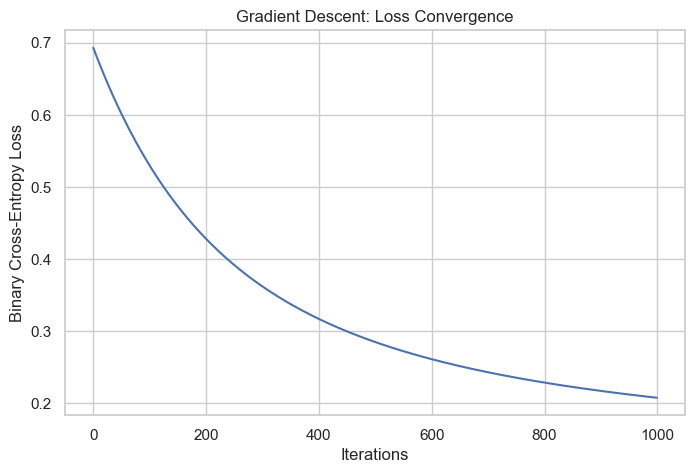

Manual GD Logistic Regression Accuracy: 0.9475


In [18]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_loss(y, y_hat):
    return -np.mean(y * np.log(y_hat + 1e-9) + (1 - y) * np.log(1 - y_hat + 1e-9))

# For binary classification demonstration, let's predict if Job_Status is 'Modified' (class 1)
y_train_binary = (y_train == 1).astype(int)
y_test_binary = (y_test == 1).astype(int)

# Hyperparameters
learning_rate = 0.01
iterations = 1000
m, n = X_train_scaled.shape

# Initialize weights and bias
weights = np.zeros(n)
bias = 0
losses = []

# Gradient Descent Loop
for i in range(iterations):
    # Forward pass
    linear_model = np.dot(X_train_scaled, weights) + bias
    y_hat = sigmoid(linear_model)

    # Compute loss
    loss = compute_loss(y_train_binary, y_hat)
    losses.append(loss)

    # Backward pass (Gradients)
    dw = (1 / m) * np.dot(X_train_scaled.T, (y_hat - y_train_binary))
    db = (1 / m) * np.sum(y_hat - y_train_binary)

    # Update parameters
    weights -= learning_rate * dw
    bias -= learning_rate * db

# Plotting the loss curve
plt.figure(figsize=(8, 5))
plt.plot(losses)
plt.title("Gradient Descent: Loss Convergence")
plt.xlabel("Iterations")
plt.ylabel("Binary Cross-Entropy Loss")
plt.show()

# Predictions
test_linear = np.dot(X_test_scaled, weights) + bias
test_preds = (sigmoid(test_linear) > 0.5).astype(int)
print(f"Manual GD Logistic Regression Accuracy: {accuracy_score(y_test_binary, test_preds):.4f}")

## 9. Deep Dive: Manual Softmax Regression Implementation

Extending the concept to multi-class classification using Softmax Regression.

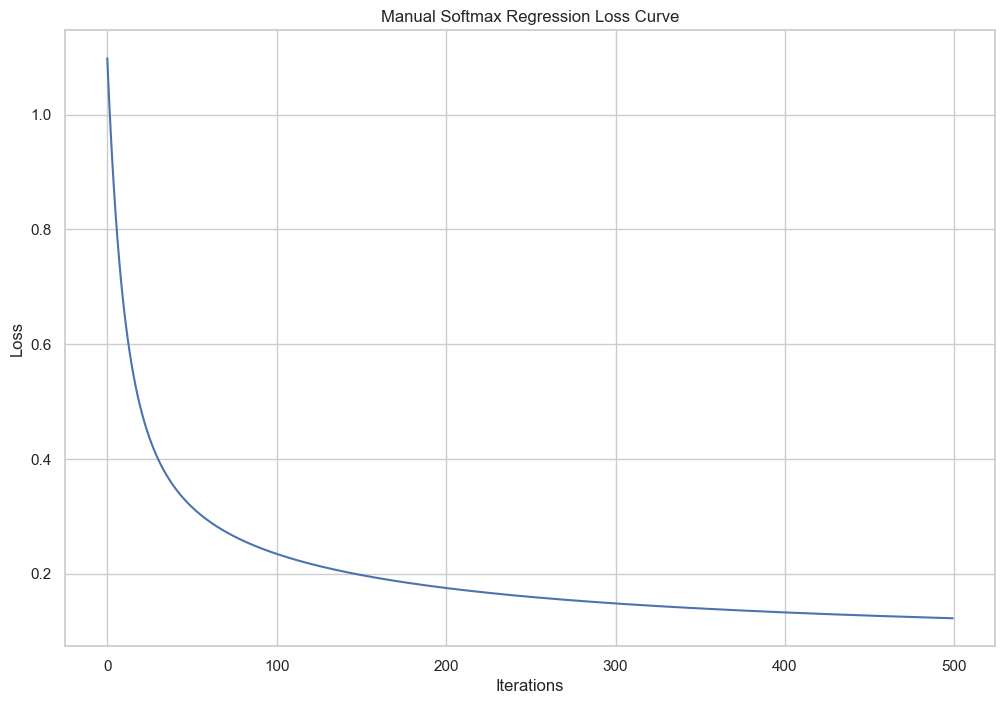

In [19]:
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# Hyperparameters
alpha = 0.1
epochs = 500
m, n = X_train_scaled.shape
k = len(np.unique(y_train))

# Initialize weights
theta = np.zeros((n + 1, k))
X_train_b = np.c_[np.ones((m, 1)), X_train_scaled]
Y_onehot = pd.get_dummies(y_train).values

losses = []
for i in range(epochs):
    scores = np.dot(X_train_b, theta)
    probs = softmax(scores)
    gradient = np.dot(X_train_b.T, (probs - Y_onehot)) / m
    theta -= alpha * gradient
    loss = -np.mean(np.sum(Y_onehot * np.log(probs + 1e-9), axis=1))
    losses.append(loss)

plt.plot(losses)
plt.title("Manual Softmax Regression Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()

Conclusion and Key Insights
Model Performance: The Random Forest model achieved the highest accuracy, effectively capturing non-linear relationships in the data.
Key Drivers: Feature importance analysis revealed that Automation_Risk and AI_Adoption_Level are the most significant predictors of job status changes, followed by Years_Experience and Productivity_Change_%.

AI Impact: A significant portion of jobs are being 'Modified' (40.05%) rather than 'Replaced' (5.30%), suggesting a shift in skill requirements and role evolution rather than total displacement. The majority of jobs remain 'Unchanged' (54.65%), indicating that AI integration is selective and context-dependent.

Industry Variations: Jobs in high-automation-risk industries (e.g., Manufacturing, Content Creation) show higher replacement rates, while roles requiring complex human judgment (e.g., Healthcare, Education) tend toward modification or stability.

Salary Implications: Modified roles often show salary adjustments (both increases and decreases), highlighting the economic restructuring accompanying AI adoption

FUTURE WORK:

Deep Learning: Implementing a Neural Network using TensorFlow/PyTorch for potentially higher predictive power.

Unsupervised Learning: Clustering employees to identify latent groups most at risk of displacement.

Temporal Analysis: Incorporating time-series data to track job status evolution over time.

Deployment: Creating a Flask/Streamlit app to predict job impact for new employee/role data points.

Explainable AI: Integrating SHAP/LIME for more granular, interpretable feature contributions at the individual prediction level

In [20]:
import joblib
import os

# Create a folder to keep things organized
os.makedirs("ml_artifacts", exist_ok=True)

# Save artifacts - use X_train.columns to ensure exact feature alignment with model
joblib.dump(best_brf, "ml_artifacts/best_brf_model.pkl")
joblib.dump(scaler, "ml_artifacts/scaler.pkl")
joblib.dump(le, "ml_artifacts/label_encoder.pkl")
joblib.dump(X_train.columns.tolist(), "ml_artifacts/feature_names.pkl")

print("✅ Model, scaler, encoder, and feature names saved successfully!")

✅ Model, scaler, encoder, and feature names saved successfully!
